# Modelagem do modelo de Krönig-Penney Contínuo

## Introdução ao potencial de Krönig-Penney

O modelo de Krönig-Penney representa uma rede cristalina de átomos, usado para modelar materiais cristalinos simples [1]. Basicamente, este modelo é a extensão dos modelos de Poço e Duplo Poço Finitos, pois considera infinitos poços finitos. Com este modelo unidimensional periódico, já é possível identificar características de materiais cristalinos, como vetor de Bloch, zonas de Brillouin e bandas de energia - incluindo gaps [1]. A figura abaixo apresenta o potencial do modelo, revelando sua estrutura periódica.

<center> 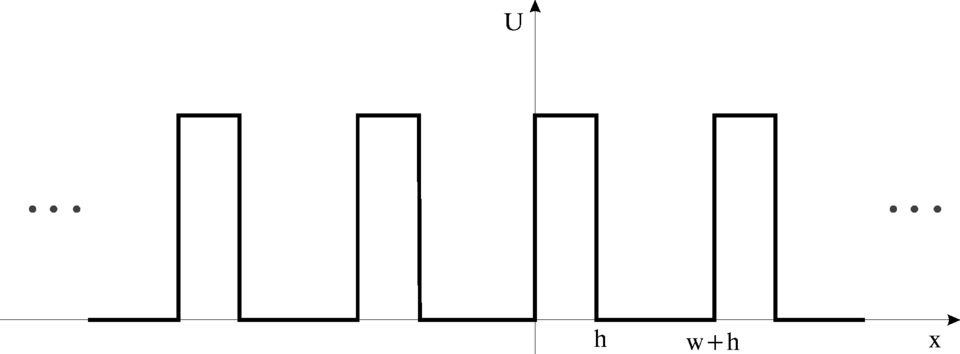<center>
<center> Figura 1: Potencial no modelo de Krönig-Penney. Fonte: https://es.wikipedia.org/wiki/Modelo_de_Kronig-Penney <center>

Na modelagem do presente trabalho optou-se trabalhar com uma versão contínua do modelo de Krönig-Penney. Para representá-lo de forma contínua usou-se uma função cosseno da seguinte forma:

$$
V(x) = V_0 \, \cos\left(\frac{2\pi}{a} x\right) 
$$

Em que $V_0$ é a amplitude da onda, o valor de potencial que define as barreiras que separam os poços e  $\frac{2\pi}{a}$ é a frequência da onda, definida assim para que tivesse período espacial $a$ e os vetores de Bloch estivessem no intervalo $(-\frac{\pi}{a}, \frac{\pi}{a})$ [1].

## Importações

In [1]:
from scipy.sparse.linalg import eigsh
from scipy import sparse

import matplotlib.pyplot as plt
import numpy as np 

## Definição de constantes e parâmetros

Além de constantes físicas (massa do elétron, constante de Planck reduzida e elétron-volt), são definidos parâmetros para a modelagem, são eles:

 - `a`: período espacial do sólido, a distância entre o núcleo de um átomo e o seguinte;
 - `V0`: amplitude do potencial, a energia máxima de cada poço (acima dela o elétron não estará mais confinado);
 - `num_bandas`: número de bandas de energia que serão calculadas (n primeiras);
 - `N`: número de pontos na malha para cálculo por diferenças finitas.

In [6]:
# Constantes físicas
m = 9.11e-31       # Massa elétron (kg)
hbar = 1.054e-34   # Constante de Planck Reduzida (J.s)
eV = 1.602e-19     # 1 elétron-volt (J)

# Parâmetros para modelagem
a = 1e-9           # Periodo espacial
V0 = 1 * eV        # Amplitude do potencial
num_bandas = 5     # Número de bandas que são calculadas
N = 200            # Número de pontos

## Definindo Arrays iniciais

São criados os arrays com os pontos espaciais da malha (`X`), com os vetores de Bloch na malha (`K`) e com os valores do potencial para cada ponto espacial na malha (`V`).

In [5]:
X = np.linspace(0, 5*a, N)             # Array da malha -> 5 períodos espaciais
K = np.linspace(-np.pi/a, np.pi/a, N)  # Array de vetores de Bloch
V = V0 * np.cos((2 * np.pi * X)/a)     # Array com os valores do potencial para cada ponto na malha

## Visualizando o potencial

Com os parâmetros para o modelo definidos, é possível mostrar exatamente o potencial estudado. Abaixo está um código que constrói o plot do potencial.

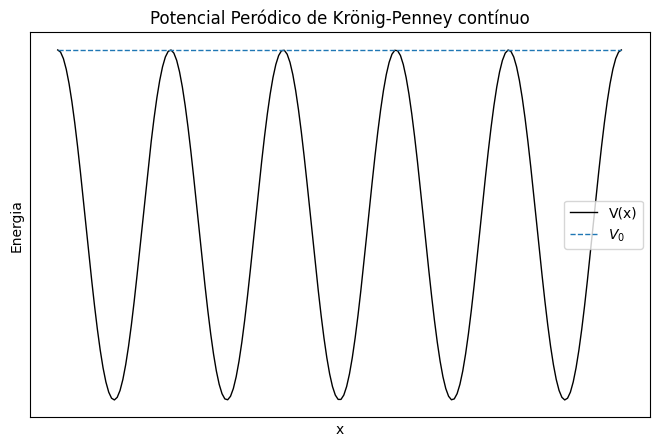

In [7]:
# ------------------- PLOT: Potencial -------------------
plt.figure(figsize=(8, 5))

# Potencial do poço
plt.plot(X*1e9, V/eV, 'k-', linewidth=1, label='V(x)')
plt.plot(X*1e9, [V0/eV]*len(X), linestyle='--', linewidth=1, label='$V_0$')

plt.xlabel('x')
plt.ylabel('Energia')
plt.title('Potencial Peródico de Krönig-Penney contínuo')
plt.legend(loc='center right')

# Omitindo valores nos eixos
plt.xticks([])   # remove números do eixo x
plt.yticks([])   # remove números do eixo y

# Salvar figura 
plt.savefig("Resultados/potencial_kronig_penney.png", dpi=300, bbox_inches='tight')

plt.show()

## Modelagem via Diferenças Finitas

O método das Diferenças Finitas oferece uma aproximação para as derivadas de segunda ordem e permite que a equação diferencial seja representada por matrizes. A primeira etapa da modelagem, portanto, foi aplicar o método à Equação de Schrödinger unidimensional e independente do tempo. Ou seja, aplicá-lo a seguinte equação:

$$
-\frac{\hbar^{2}}{2m}\,\frac{\mathrm d^2\, \psi(x)}{\mathrm d x^2} + V(x)\,\psi(x) = \mathrm E \, \psi(x)
$$

Pelo método das diferenças finitas, a aproximação para a derivada de segunda ordem é: 
 
$$
\frac{X_{i-1} - 2X_{i} + X_{i+1}}{\ell^2}
$$

Assim, a Equação de Schrödinger pode ser escrita como: 

$$
-\frac{\hbar^2}{2m}\bigg[\frac{\psi_{i-1} - 2\psi_{i} + \psi_{i+1}}{\ell^2}\bigg] + V(x) \psi_i = E\psi_i 
$$

Essa equação representa um sistema linear de equações, o qual pode ser reescrito na forma matricial, caso em que o Hamiltoniano assume a forma

$$
\hat{H}_{df}=
-\frac{\hbar^2}{2m\ell^2}
\begin{bmatrix}
-2 & 1 & 0 & \cdots & 0 \\
1 & -2 & 1 & \cdots & 0 \\
0 & 1 & -2 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & 1 & -2
\end{bmatrix} + V(x)\,I
$$

O operador $\hat{H}_{df}$ é a aproximação do Hamiltoniano ($\hat{H}$) no método das diferenças finitas. Assim, o problema pode ser reumido ao problema de autovalor: 

$$
\hat{H}_{df}\psi=E\psi
$$

In [ ]:
# Definindo o passo
passo = X[1] - X[0]

# Definindo os termos do Hamiltoniano
diag_pri = -2 * np.ones(N)     # Diagonal principal
diag_sec = 1 * np.ones(N-1)    # Diagonal secundaria 

termo_lateral = ((hbar**2)/(2*m*(passo**2))) # Termo que multiplica a matriz esparsa

potenciais = sparse.diags(V, 0) # Matriz com os potenciais 

## Resolução do problema de autovalor

Para encontrar as bandas de energia do material é preciso compreender a condição de contorno utilizada para resolver o problema de autovalor apresentado. A condição de contorno utilizada foi a periódica de Bloch, que consiste em afirmar:

$$
\psi(x) = \psi(x + a)
$$

Essa relação estabelece a periodicidade. Dela retira-se um Hamiltoniano ligeiramente diferente, com exponenciais complexos nos cantos superior direito e inferior esquerdo [1].

$$
\hat{H}_{df}=
-\frac{\hbar^2}{2m\ell^2}
\begin{bmatrix}
-2 & 1 & 0 & \cdots & e^{-ika} \\
1 & -2 & 1 & \cdots & 0 \\
0 & 1 & -2 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & 1 \\
e^{ika} & 0 & 0 & 1 & -2
\end{bmatrix} + V(x)\,I
$$

Em que $k$ é o chamado vetor de Bloch. Para a física, o importante sobre ele é que o intervalo $(-\frac{\pi}{a}, \frac{\pi}{a})$ de valores de $k$ para estruturas unidimensionais determina a primeira zona de Brillouin. Esta zona é repetida na periodicidade do cristal, portanto basta estudar a estrutura de bandas de energia nela para compreender o todo [1].

In [4]:
# Resolvendo o Problema de Autovalor para cada vetor de Bloch
E = [] # Define E(k)

for k in K:
    H = termo_lateral * sparse.diags([diag_sec, diag_pri, diag_sec], offsets=[-1,0,1]) + potenciais # Hamiltoniano
    
    # Define como matriz complexa
    H = H.astype(complex)
    
    # Implementa condição de Bloch
    H = H.tolil()                                    # Muda o formato da matriz para alterar valor específico
    H[0, -1] = termo_lateral * np.exp(-1j * k * a)   # Altera valor superior direito para e^-ika
    H[-1, 0] = termo_lateral * np.exp(1j * k * a)    # Altera valor inferior esquerdo para e^ika
    H = H.tocsr()                                    # Muda o formato da matriz para o anterior
    
    E_k, _ = eigsh(H, k=num_bandas, which="SR") # Encontra os num_estados menores autovalores e autofunções

    # Garante que tem apenas parte real
    E_k = np.real(E_k)

    # Ordena do estado fundamental em diante
    E_k = E_k[np.argsort(E_k)]

    # Acrescenta valor de E_k
    E.append(E_k)

## Plot da solução

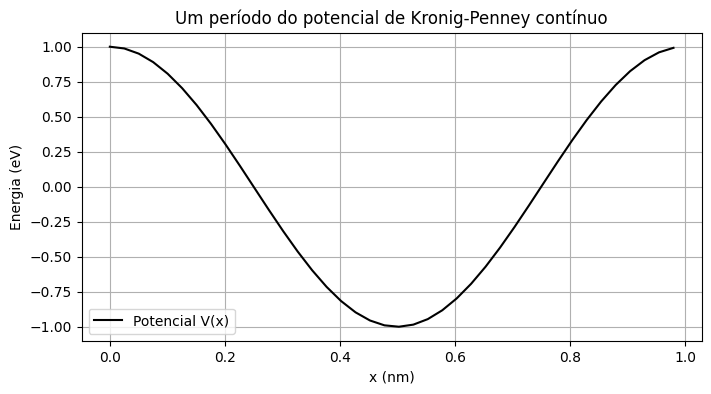

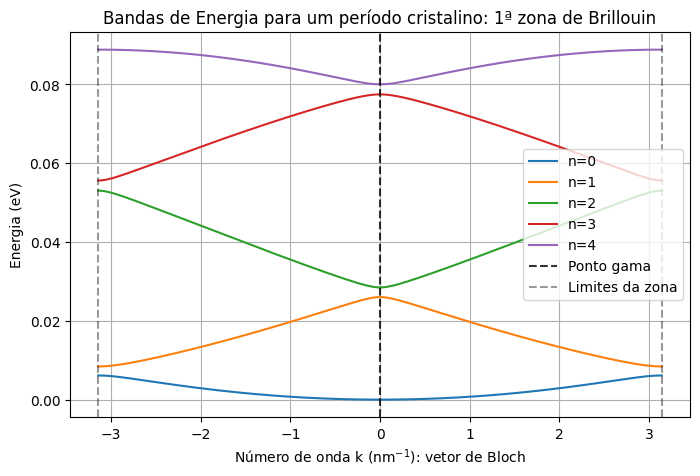

In [5]:
# ------------------- PLOT 1: Potencial -------------------
plt.figure(figsize=(8, 4))
plt.plot(X[X <= a]*1e9, (V[X <= a])/eV, 'k-', label='Potencial V(x)')
plt.xlabel('x (nm)')
plt.ylabel('Energia (eV)')
plt.title('Um período do potencial de Kronig-Penney contínuo')
plt.legend()
plt.grid(True)
plt.show()

# ------------------- PLOT 2: Energias -------------------
E = np.array(E)  # transforma lista de listas em matriz (N_k x num_estados)
E = E - np.min(E)  # zero no estado fundamental

plt.figure(figsize=(8, 5))
for n in range(num_bandas):
    plt.plot(K*1e-9, E[:, n]/eV, label=f'n={n}')
plt.axvline(0, color='k', linestyle='--', alpha=0.8, label='Ponto gama')
plt.axvline(np.pi, color='k', linestyle='--', alpha=0.4, label='Limites da zona')
plt.axvline(-np.pi, color='k', linestyle='--', alpha=0.4)
plt.xlabel(r'Número de onda k (nm$^{-1}$): vetor de Bloch')
plt.ylabel('Energia (eV)')
plt.title('Bandas de Energia para um período cristalino: 1ª zona de Brillouin')
plt.legend(loc='center right')
plt.grid(True)
# Salvar figura 
plt.savefig("Resultados/bandas_kronig_penney.png", dpi=300, bbox_inches='tight')
plt.show()

Note as linhas contínuas no gráfico de bandas de energia, cada uma delas determina uma banda de energia permitida diferente. Ademais, os espaços entre elas sem valores definidos de energia são os chamados *band gaps*.

## Referência

[1] DATTA, Supriyo. Quantum transport: atom to transistor. 1. ed. New York: Cambridge University Press, 2005.